In [1]:
!pip install statsmodels

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

import statsmodels.api as sm

%matplotlib inline

In [3]:
plt.rcParams['figure.figsize'] = [10, 7.5]

## Dataset 

In [4]:
data = pd.read_csv('shampoo.csv')

In [5]:
data

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3
5,1-06,168.5
6,1-07,231.8
7,1-08,224.5
8,1-09,192.8
9,1-10,122.9


In [6]:
data.head()

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3


In [7]:
data.head(10)

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3
5,1-06,168.5
6,1-07,231.8
7,1-08,224.5
8,1-09,192.8
9,1-10,122.9


### Dataset summary 

In [8]:
data.describe()

,Sales
count,36.000000
mean,312.600000
std,148.937164
min,119.300000
25%,192.450000
50%,280.150000
75%,411.100000
max,682.000000


In [9]:
data.Sales.mean()

np.float64(312.59999999999997)

In [10]:
data.Sales.std()

148.93716412347473

## Visualizations 
### Histograms

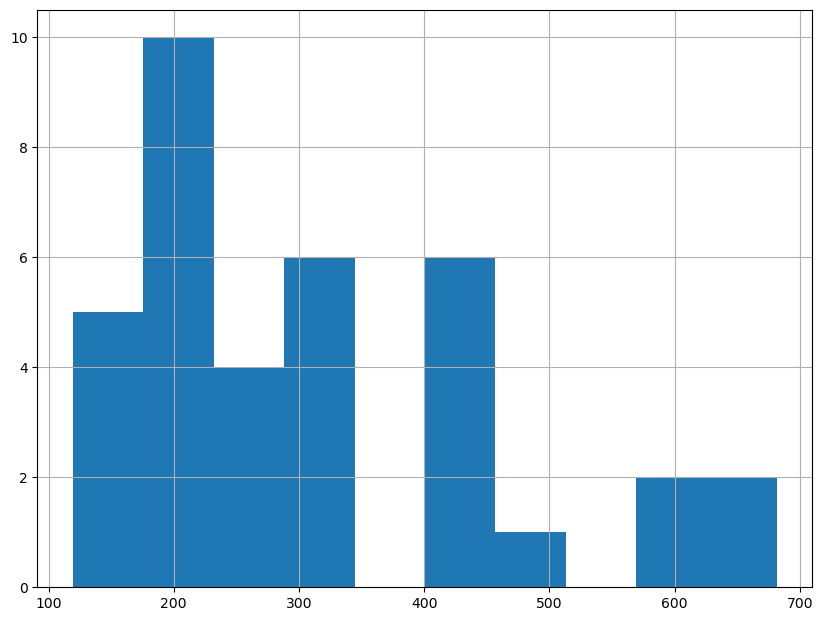

In [11]:
data.Sales.hist()
plt.show()

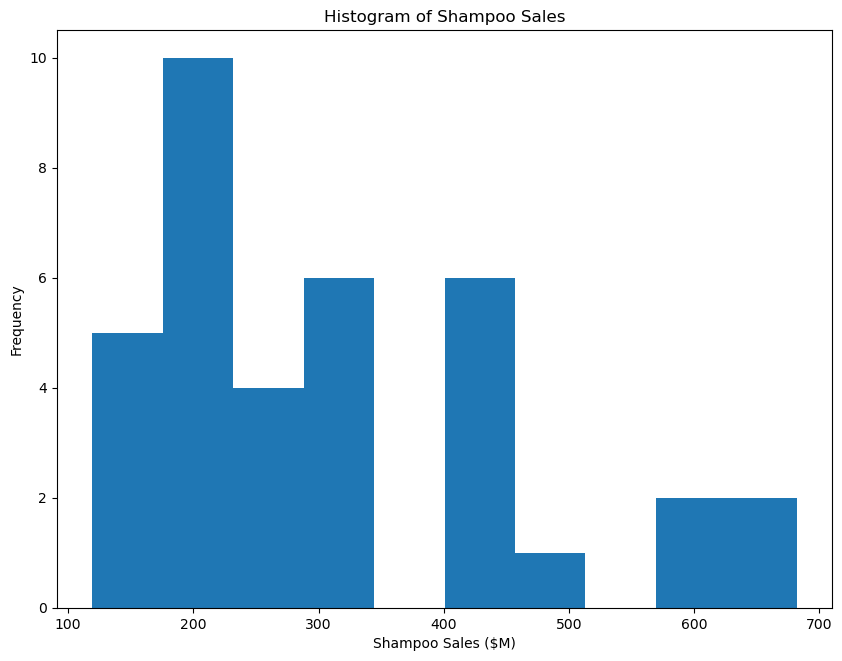

In [12]:
plt.hist(data['Sales'])
plt.title('Histogram of Shampoo Sales');
plt.xlabel('Shampoo Sales ($M)');
plt.ylabel('Frequency');
plt.show()

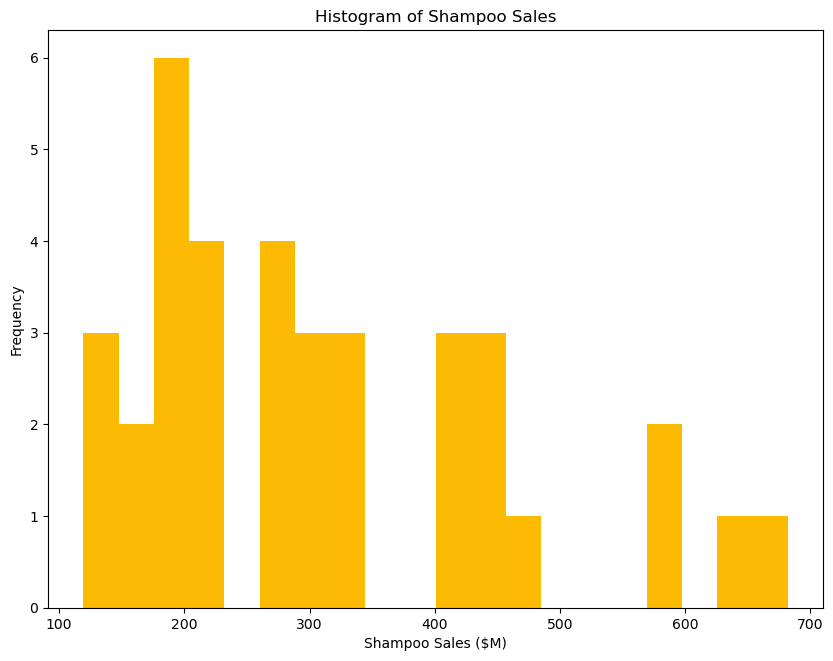

In [13]:
plt.hist(data['Sales'], bins=20, color='#fcba03')
plt.title('Histogram of Shampoo Sales');
plt.xlabel('Shampoo Sales ($M)');
plt.ylabel('Frequency');
plt.show()

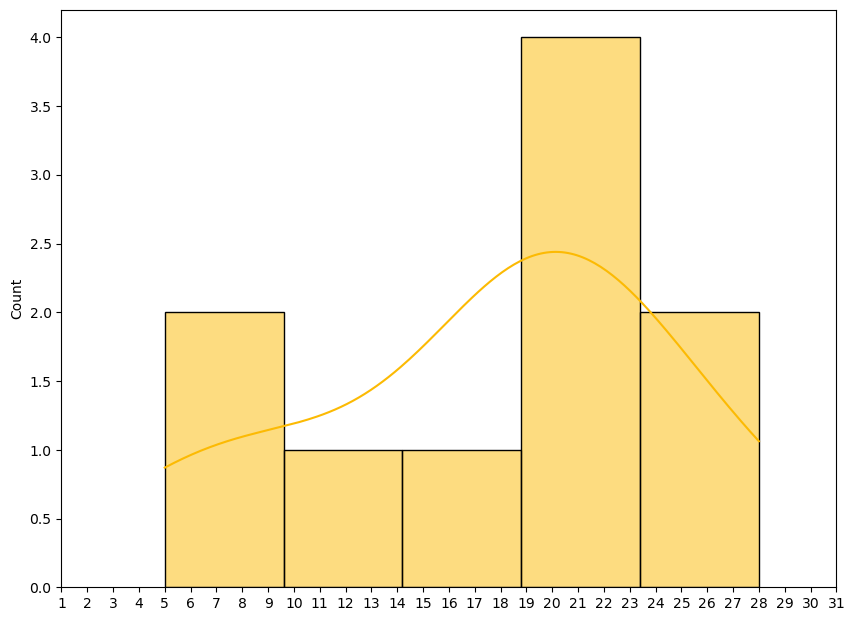

In [14]:
data = [5,8,12,18,19,19.9,20.1,21,24,28] 

fig, ax = plt.subplots()
sns.histplot(data, ax=ax, kde=True, color='#fcba03')  # distplot is deprecate and replaced by histplot
ax.set_xlim(1,31)
ax.set_xticks(range(1,32))
plt.show()

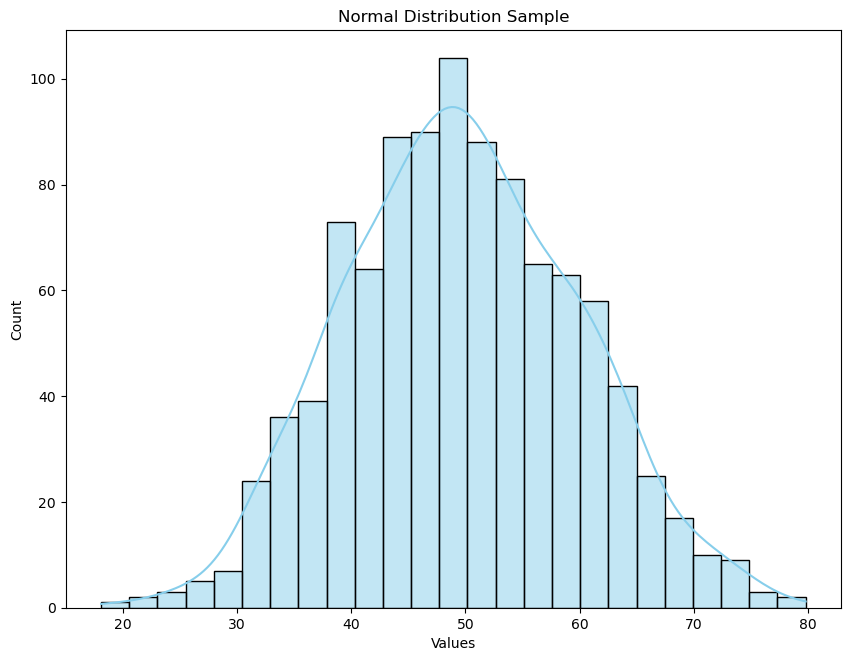

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate random data
data_points = np.random.normal(loc=50, scale=10, size=1000)

# Plot histogram with a KDE curve
sns.histplot(x=data_points, bins=25, kde=True, color='skyblue')

plt.title("Normal Distribution Sample")
plt.xlabel("Values")
plt.ylabel("Count")
plt.show()

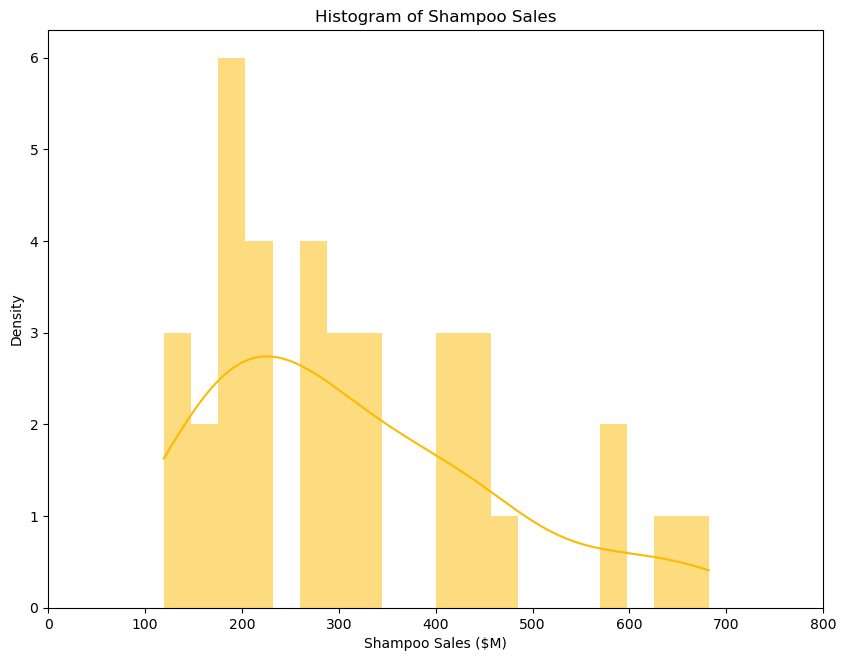

In [16]:
data = pd.read_csv('shampoo.csv')
ax = sns.histplot(data=data, x="Sales", kde=True, color='#fcba03', bins= 20)

# Iterate through the patches (bars) and set edgecolor to 'none'
for patch in ax.patches:
    patch.set_edgecolor('none')
plt.title('Histogram of Shampoo Sales');
plt.xlabel('Shampoo Sales ($M)');
plt.ylabel('Density');
ax.set_xlim(0, 800)
plt.show()

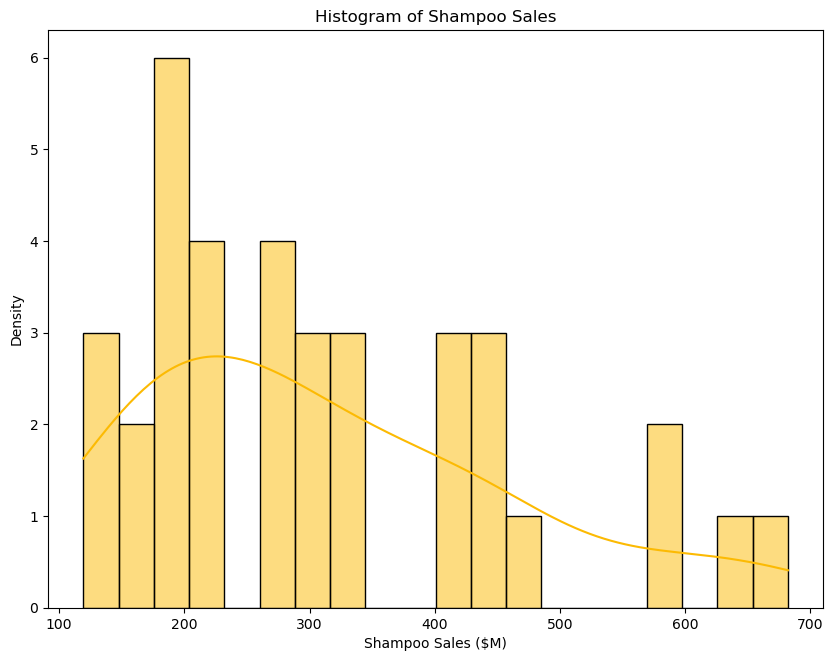

In [17]:
sns.histplot(data['Sales'], bins=20,  kde=True, color='#fcba03');
plt.title('Histogram of Shampoo Sales');
plt.xlabel('Shampoo Sales ($M)');
plt.ylabel('Density');
plt.show()

### Scatter plots 

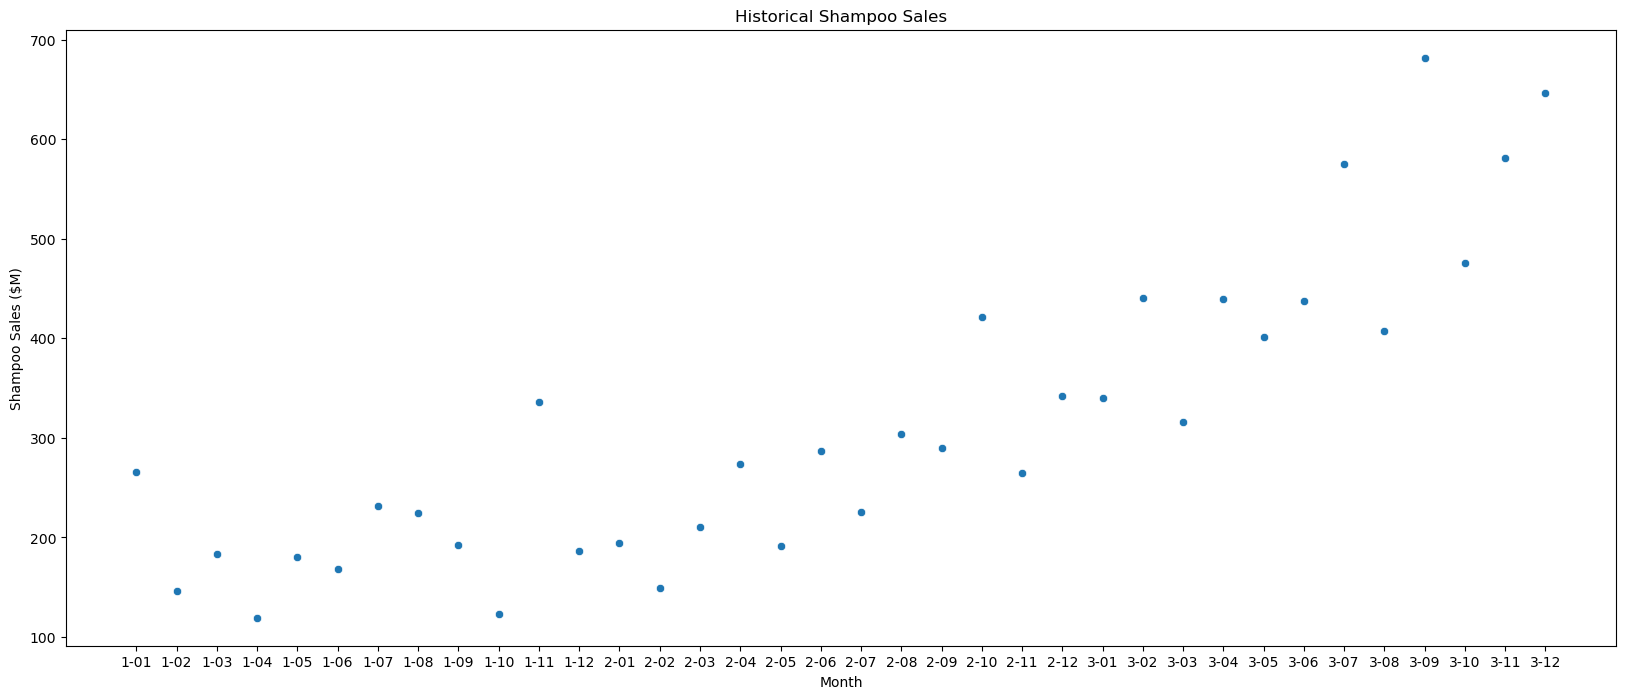

In [18]:
plt.figure(figsize=(20, 8))

sns.scatterplot(x=data['Month'], y=data['Sales']);
plt.title('Historical Shampoo Sales');
plt.ylabel('Shampoo Sales ($M)');
plt.xlabel('Month');
plt.show()

## Inferential Statistics 

In [19]:
# Dataset from here: https://www.co2.earth/historical-co2-datasets
co2_data = pd.read_csv('co2_dataset.csv')

co2_data.head()

,year,data_mean_global,data_mean_nh,data_mean_sh
0,0,277.454,277.454,277.454
1,1,277.137,277.137,277.137
2,2,277.160,277.160,277.160
3,3,277.158,277.158,277.158
4,4,277.157,277.157,277.157


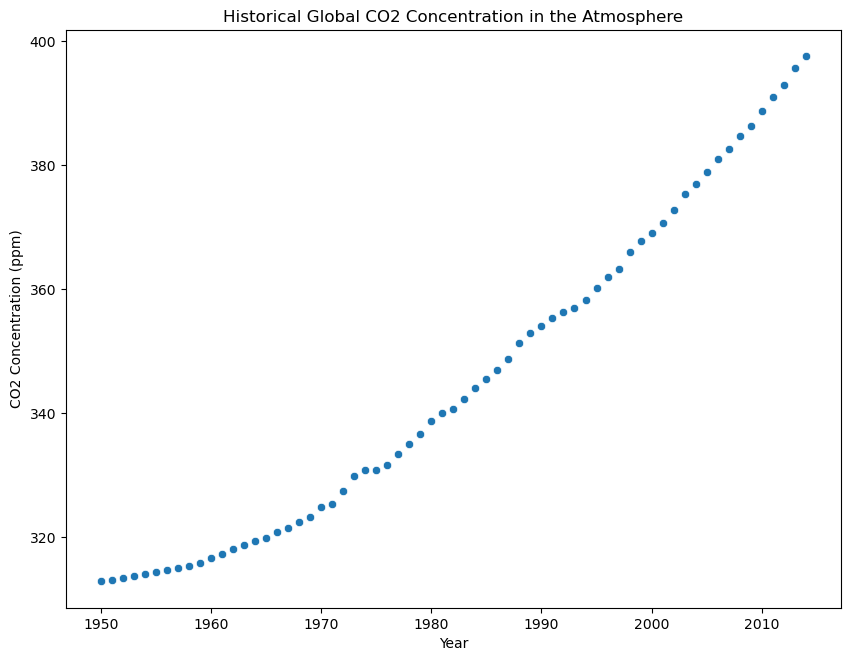

In [20]:
# Let's only consider the data from the year 1950
X = co2_data['year'].values[1950:]
y = co2_data['data_mean_global'].values[1950:]

sns.scatterplot(x=X, y=y);
plt.title('Historical Global CO2 Concentration in the Atmosphere');
plt.ylabel('CO2 Concentration (ppm)');
plt.xlabel('Year');
plt.show()

In [21]:
X = co2_data['year'].values[1950:].reshape(-1, 1)
y = co2_data['data_mean_global'].values[1950:].reshape(-1, 1)

reg = LinearRegression()

reg.fit(X, y)

print(f"The slope is {reg.coef_[0][0]} and the intercept is {reg.intercept_[0]}")

The slope is 1.358871192943465 and the intercept is -2348.0338300545372


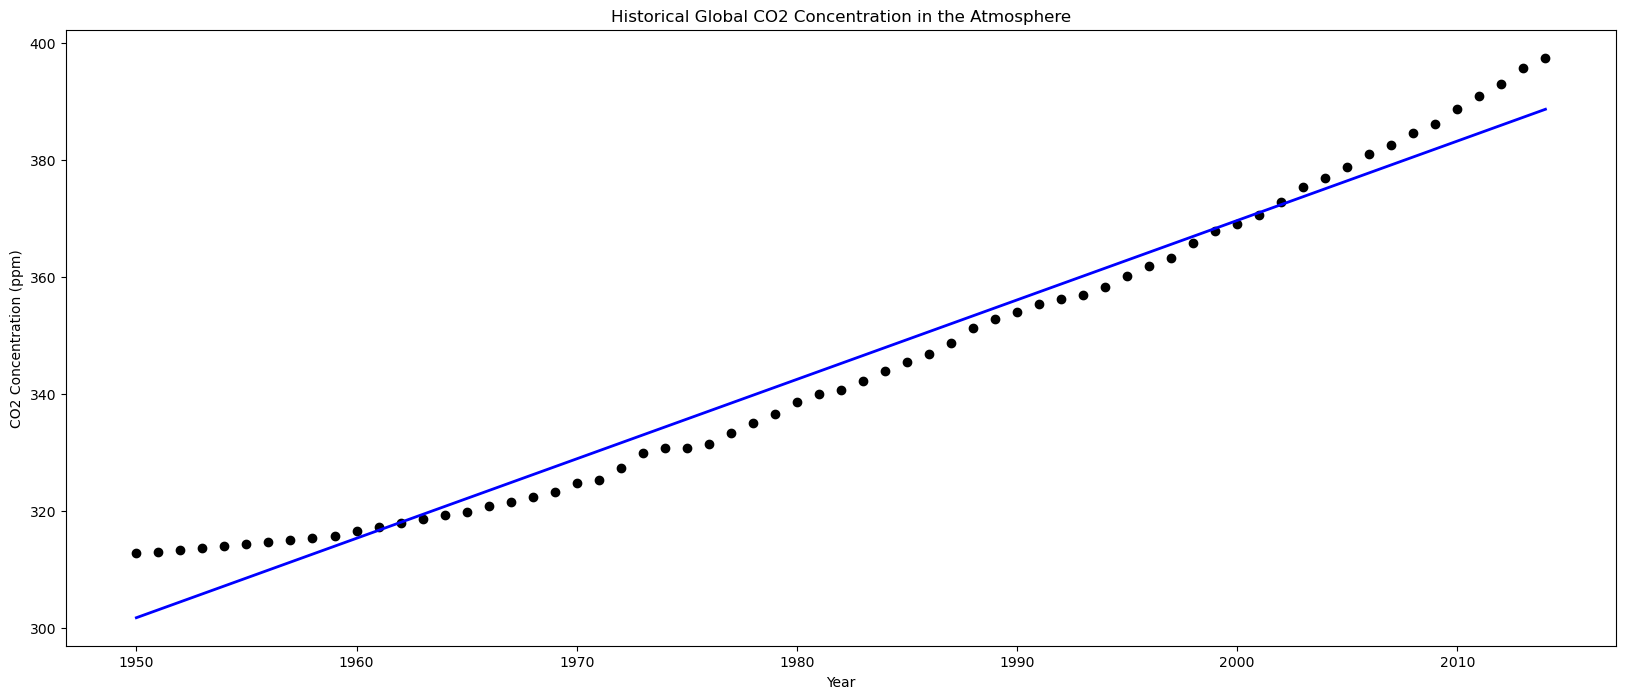

In [22]:
X = co2_data['year'].values[1950:]
y = co2_data['data_mean_global'].values[1950:]

predictions = reg.predict(X.reshape(-1, 1))

plt.figure(figsize=(20, 8))
plt.scatter(X, y,c='black')
plt.plot(X, predictions, c='blue', linewidth=2)
plt.title('Historical Global CO2 Concentration in the Atmosphere');
plt.ylabel('CO2 Concentration (ppm)');
plt.xlabel('Year');
plt.show()

In [23]:
X = sm.add_constant(co2_data['year'].values[1950:])
model = sm.OLS(co2_data['data_mean_global'].values[1950:], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     2073.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           6.40e-50
Time:                        15:28:06   Log-Likelihood:                -189.19
No. Observations:                  65   AIC:                             382.4
Df Residuals:                      63   BIC:                             386.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2348.0338     59.161    -39.689      0.0

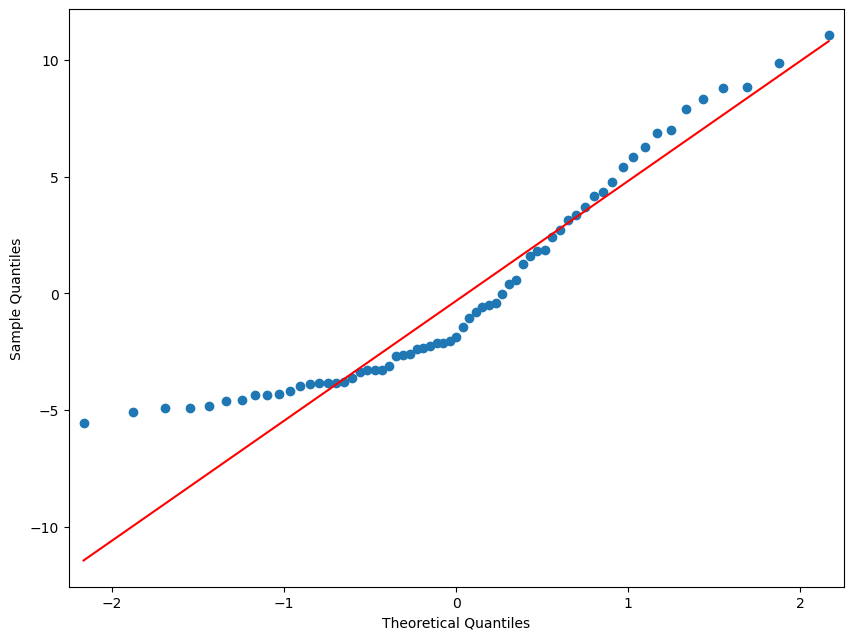

In [24]:
residuals = model.resid
qq_plot = sm.qqplot(residuals, line='q')

plt.show()

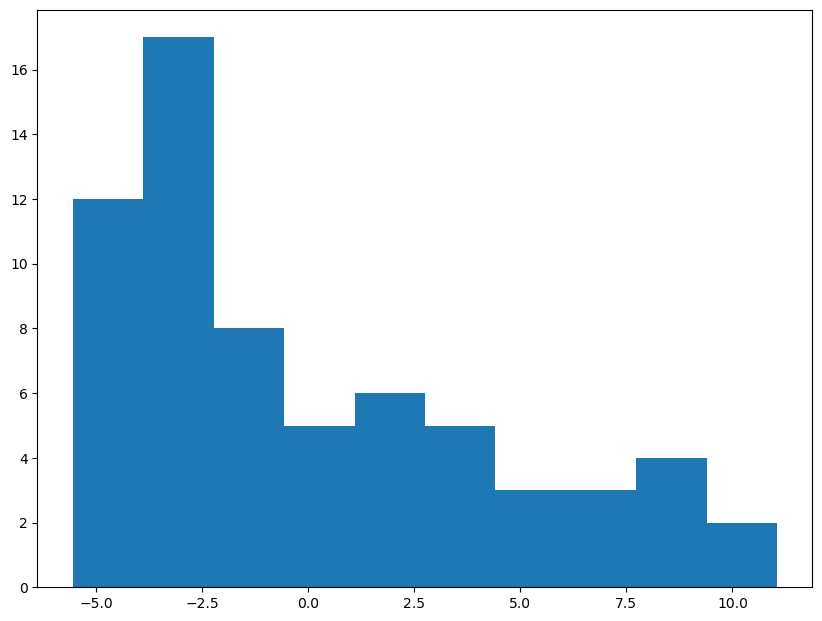

In [25]:
plt.hist(residuals);
plt.show()